# Feature analysis — vol-over-rate (σ_ev / λ_ev)

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

To analyse a new feature, copy this notebook and change the parts specific to the feature:
**what it is and why** (§1), **its exact definition** (§2), and **its builder** — the
`vol_over_rate` function in §3. The data loading, the checks, and the plots adapt on their own.

**The example** is `vol_over_rate`: a venue's volatility-per-move `σ_ev` divided by its move-rate
`λ_ev`, a non-negative ratio in units of **seconds** — roughly *how much volatility a venue packs
into one move, times how long a move takes*. It is high when moves are **big and slow**, low when
moves are **small and fast**. It is built **per venue** (byb, okx, bin) from that venue's own
mid-moves, swept over the `σ_ev` and `λ_ev` spans independently. This is a **regime descriptor**
(a control), not an order-flow alpha — which changes how the gates read it (§5/§6).

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a second implementation reproduces the feature on real data, so the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale* — and the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is not ship-done.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and you want it gone, dividing
by the yardstick is **one option** for removing it (only *when applicable* — you can't always
divide the regime out of a feature). Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`)
but **updated between trades** — they react to every byb mid-move, so they read live at every
instant. They use one fixed span, `YARDSTICK_N` for the **controls**; the feature itself sweeps the
two spans independently (any feature may use the yardstick span too). (`σ_ev` is
the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many non-move
trades cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted byb move-count `W` (the same
`W` that is `σ_ev`'s denominator) ÷ the exp-weighted seconds-per-trade = byb's moves per second.) Like every average here, they live
on the trade-tick clock — never wall-clock or a hard window. **The model's own yardsticks are byb's**;
this feature computes the *same construction* for each venue, which is the whole point of the
per-exchange axis.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed** — for every count `k`, take the price head's `k`-move
distribution, weight it by the rate head's probability of exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful: they feed the two factors that
multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. `vol_over_rate` lives squarely in that picture — it is literally *per-move
size ÷ event rate*, a one-number summary of the subordinator's local state.

Every feature here feeds one or both heads, and borrows the matching yardstick when it needs
to be made comparable across markets. Two questions recur below: does a feature's *signed*
value predict the move (price head), and does its *magnitude* predict how many moves come
(rate head)? Those are diagnostics — the model is fed the **signed** feature for *both* heads,
and the rate head learns the magnitude (and how features cancel or reinforce) on its own. And they
are **marginal screens** — does the feature carry signal worth feeding — **not** measures of
distributional fit: the model's actual targets are the count distribution `P(K = k)` and the
count-conditioned price family `D_k` mixed above, fit downstream, not what these rank-ICs measure
(§7 inspects the realised count/return distributions by feature bucket).

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for every exchange and keep them all.
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. For a
  poolable feature (this one *is* poolable — a per-exchange number, not a gap *between*
  exchanges), first check per-exchange vs single vs pooled across time-scales (§9).
- **Don't normalize reflexively.** `σ_ev/λ_ev` is *already a ratio of two EMAs* — it needs **no**
  further vol/rate division. Dividing it again by `σ_ev` would just hand back `1/λ_ev`.
- **Don't invent your own vol/rate scale.** When you *do* normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — but for a
  feature that *is* a regime descriptor, marginal-over-its-own-controls is **circular**, so judge
  the control on its **standalone** signal (and its cross-venue legs as a genuine lead test).
- **Don't ship a feature without the §4 parity check** — a second, production-style build reproducing it on real data.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't over-transform for the network.** Pick the lightest reshaping that works.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what
  would prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — each venue's
  `σ_ev`, `λ_ev`, the seconds-per-trade leg — is an exponential moving average
  **decayed once per tick of the one shared trade clock** (one tick per trade-timestamp across **all** venues; simultaneous prints count once; `α = 2/(span+1)`) yet **taking in a fresh value at most once per timestamp that carries a relevant event** (a venue mid-move; a byb move — same-timestamp events as one update, never stale between trades), **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one scalar
  per average, no ring buffers) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 parity check re-checks here.
- **Do make every EMA react to relevant events as they land — never let it read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update its value* at **each timestamp that carries a
  relevant event** (same-timestamp events aggregated to one update). For `σ_ev`/`λ_ev`, that relevant event is a venue
  mid-move: it injects that move's `r²`. A value that ignores its own moves since the last clock
  read is **stale** — wrong, and a silent source of lag. The choice of EMA *and when it updates* is what makes
  the read well-behaved — pick both deliberately (see the "Choosing the EMA" section).
- **Do inject at most one EMA sample per timestamp, and decay once per shared-trade-clock tick — this
  never changes.** At each timestamp an EMA injects **one** sample *iff* a relevant event for that EMA
  lands there: for `σ_ev`, a venue mid-move. A timestamp with only **irrelevant** trades injects nothing for that EMA, yet it still
  **ticks** (decays) once *iff* a trade lands, on the one **shared** trade clock
  (one tick per trade-timestamp across **all** venues, simultaneous prints counting once). Inject and
  decay are independent and neither ever fires more than once per timestamp, whatever the feature.
  Records sharing a timestamp are **one** sample, not a sequence: same-timestamp aggregation sets only
  that sample's **value** — never the number of samples, never the number of ticks. The
  level-read face of the same trap: `σ_ev` counts squared mid-*moves*, so N simultaneous records
  fabricate N−1 phantom moves and inflate volatility (one sample per
  timestamp keeps it **bit-exact**). Time-order matters only on the clock — a timestamp with trades
  advances it **once**, not once per print.
- **Do read a sparse flow as `E / W`.** `σ_ev` is exactly such a flow — a venue moves on only *some*
  events — so it is two EMAs (the squared-return sum `E` and the move-count `W`), read as the ratio
  `√(E/W)`, which cancels the in-between decay and the warm-up bias. `λ_ev` reuses that same `W`,
  divided by an EMA of seconds-per-trade. This is also why per-venue stats fall out of the **one
  shared clock**: the `E/W` cancels the foreign-event decay, so each venue's own-clock EMA is
  recovered at a rescaled span (tight at large N, fraying at small N — exactly where cross-venue
  lead/lag lives). (That merged-clock ↔ own-clock equivalence is what
  `notebooks/03_ema_clock_validation.ipynb` validates.)
- **Do test against both heads — but feed both the *signed* feature.** `vol_over_rate` is a
  non-negative magnitude (a ratio of positives), so it has no sign to speak of — it is naturally a
  **rate-head / intensity** feature. We still check both targets as diagnostics, and feed the value
  to both heads, never a pre-computed transform.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single split is only a faster screen.
- **Do use the freshest valid price per exchange.**
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads
  (here the **two** spans — `σ_ev` and `λ_ev` — swept independently).
- **Do prove regime-invariance with Gate A — never assume it.** A usable feature reads the *same* in calm and
  wild markets: its distribution must be **stable against the regime diagnostics we track** (not a proof of independence). Gate A's **control-free** checks (§6):
  **scale** (std stable across vol buckets, max/min < ~3); and — for **both the signed feature and its
  magnitude `|feature|`** (the rate head sees the signed feature but can learn its magnitude) — that it does **not track** the regime
  (`|IC(·, vol & rate level)| ≈ 0`, the monotone test) **nor leak non-monotonically** (per-decile-mean
  **dispersion** small, which catches a U-shaped leak the monotone IC misses). All are **hard** gates. A raw
  **level** (`σ_ev`, `λ_ev`, a mean trade size) usually *is* the regime and fails them — but *measure, don't
  assume*: a **ratio / bounded / normalised** form may pass, and even a ratio of two non-invariant levels can
  be invariant when they co-move (`σ_ev/λ_ev` is exactly such a ratio — we measure whether its *seconds*-scale
  is regime-stable). Never call a feature regime-invariant *or* not — nor a level useless — until
  **every** Gate A number says so. (Corollary: don't assert *any* property — invariance, a lead/lag, "it's
  circular" — you haven't measured on a real block.)
- **Don't fuse the two gates — they're independent.** *Regime invariance* (Gate A) is the feature's own
  distribution being stable across regimes; *signal* (Gate B) is what it predicts over the **invariant**
  controls. The raw vol/rate **levels aren't Gate-B controls** (they aren't valid alpha features) — putting them in
  the signal test just smuggles the Gate-A regime test back in; they serve only as the Gate-A regime *coordinate*. And **a control can be a valid feature**: when the
  feature under test *is* a regime descriptor (as this one is), marginal-over-its-own-controls is circular — judge it on its
  **standalone** signal, and never call it "redundant" from its algebra alone.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | a venue's volatility-per-move `σ_ev` divided by its move-rate `λ_ev` — a non-negative ratio (units: seconds), computed **per venue** (byb, okx, bin) and swept over the `σ_ev` and `λ_ev` spans independently |
| **feeds** | mainly the **rate head** (intensity: how busy / how fast the next moves come); checked against the price head too — both fed the value |
| **predicts** | byb's mid-price 100 ms from now — chiefly *how busy* the next 100 ms will be |

**The idea.** Split a venue's recent behaviour into "how big is a typical move" (`σ_ev`) and "how
often does it move" (`λ_ev`). Their ratio `σ_ev / λ_ev` is large when moves are **big but
infrequent** (a jumpy, lurching regime) and small when moves are **small but frequent** (a smooth,
fast-ticking regime). That contrast is a clean one-number description of the *texture* of trading,
and texture tends to persist over the next 100 ms.

**Why it should work — and why per-exchange.** Market regimes are sticky on a 100 ms scale: a market
that is currently lurching tends to keep lurching. byb's *own* `σ_ev/λ_ev` reads byb's texture
directly. But the venues are coupled and not perfectly synchronous — **okx or bin may shift its
texture a beat before byb does**, so *another* venue's `σ_ev/λ_ev` can carry information about byb's
*next* stretch that byb's own value hasn't shown yet. That is the per-exchange hypothesis: at short
spans the cross-venue legs may carry a distinct lead; at long spans the venues converge and one suffices.

**What would disprove it.** (byb leg) no relationship between byb's `σ_ev/λ_ev` and byb's forward
move-count / return-magnitude at any span. (cross-venue legs) the okx/bin `σ_ev/λ_ev` adds **no**
marginal value over byb's own — i.e. no venue leads byb's pace.

> **The circularity caveat (byb leg only).** byb's `σ_ev` and `λ_ev` are the model's vol and rate
> controls. `log(σ_ev/λ_ev) = log σ_ev − log λ_ev` is exactly `vol_level − rate_level` — an exact
> linear combination of two of the controls. So a *marginal*-over-byb's-controls gate is
> **near-circular by construction for the byb leg**, and we expect ≈0 there. That's why this feature
> is a **control** (`FEATURE_KIND = "control"`, §5): we judge it on its **standalone** signal, not a
> marginal-over-its-own-controls. **The okx and bin legs are NOT circular** — they are *other venues'*
> vol/rate, not byb's controls — so their marginal value is the honest cross-venue lead/lag test, and
> §6/§9 report it as such.

> **No fixed leader.** This feature is a per-exchange number, so we build the same `σ_ev/λ_ev` for
> **every** venue and keep them all (§9 sweeps when per-exchange / pooled beats a single venue).

## Choosing the EMA

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates at most once per timestamp that carries the EMA's own
relevant event** (same-timestamp events as one update). `σ_ev` is a **sparse flow** — a venue moves on
only *some* events — so it is the textbook case for the self-normalising `E / W` read; `λ_ev` reuses
its move-count `W`, divided by a seconds-per-trade flow read the same `E / W` way (also a
**`KernelMeanEMA`**). Choose the EMA type and injection rule for the statistic being measured.

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- `σ_ev` is a **sparse flow** — present on only *some* events — so it is a **`KernelMeanEMA`**, the
  self-normalising `E / W`: push `return²` (weight 1) only on a real mid-move, decay every trade, read
  `σ_ev = √(E/W)` = RMS move *per move*. The `W` denominator counts only the events that carry the
  quantity, so the many non-move trades cancel instead of counting as zeros.
- `λ_ev` reuses that same exp-weighted move-count `W` and divides it by a **seconds-per-trade flow** —
  also a **`KernelMeanEMA`**, read `E / W`: push that trade's `Δt` (weight 1) once per trade-timestamp,
  decay every trade-timestamp. So `λ_ev = W / E[Δt]` = mid-moves per second. (`E[Δt]` is a *dense* flow —
  one sample on every trade — so its `E / W` is just the bias-corrected per-trade mean of `Δt`.)
- A **forward-filled level** — defined at every instant (a price, a cross-venue gap) — would use
  **`LiveFrontEMA`** instead; both yardsticks here are flows, not levels, so they do **not** use it.

**Choice 2 — *when* you push a value in** (the injection clock — a *separate* decision from the decay
clock). Decay is always once per trade-timestamp; injection is only for timestamps carrying the
quantity the EMA is measuring. The allowed patterns are:

| pattern | what it weights / measures | use for |
|---|---|---|
| only on a real venue mid-move, skip irrelevant clock ticks | a **per-move mean** of `r²`; non-moves are non-observations, not zeros | `σ_ev` (the `E`, `W`) |
| once per trade-timestamp | a per-trade EMA of the gap between trades | `λ_ev`'s seconds-per-trade leg |

The trap: push a `0` on a non-move trade and "vol per move" silently becomes "vol per *trade*"
(contaminated by the trade rate). Both `σ_ev` and `λ_ev` obey the two between-trade rules:

- **React at every relevant timestamp, and read the freshest value.** Decay rides the trade clock, but the
  EMA must *update* at every mid-move (same-timestamp events as one update), and the read must reflect
  the moves since the last trade — never a stale snapshot.
- **Records sharing a timestamp are ONE update, not a sequence** — apply them all, then register a single
  update (one mid, one move, one decay).

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking. (A stray forward-fill
is the usual way to break this by accident.)

**Measured on the trade clock** — we count progress in *trades* (one tick per trade-timestamp on
any exchange — simultaneous prints are one tick), not in clock-seconds, so the feature's meaning
stays steady whether trading is fast or slow. Book updates between trades refresh what the EMAs
*read*, but do **not** advance the clock — only a trade does, decaying each EMA once. **All venues'
trades share this one clock**; each venue's `σ_ev/λ_ev` injects on its *own* mid-moves but decays on
the *shared* trade clock (the `E/W` ratio recovers each venue's own-clock statistic — see §4).

**Comparable across calm and wild markets** — `σ_ev/λ_ev` is **already a ratio**, so it needs *no*
further normalisation, and its units are **seconds** — a physical scale we can read directly. Whether that
scale is actually *regime-invariant* (whether its level holds steady across calm and wild markets) is **not**
assumed — it is **measured** by Gate A in §6, and on this block it does **not** hold: the ratio's level tracks
the vol/rate regime (it is `vol_level − rate_level` in logs), so it is a regime-*tracking* coordinate, not a
regime-invariant one. (We still build byb's `σ_ev`, `λ_ev` below: the *target* is in σ-units / count-units, and
they are the regime controls in §5.)

Put together:

**2a — The shape** (the whole idea, in one line):

`feature(venue) = σ_ev(venue) / λ_ev(venue)`     (units: seconds; high = big-and-slow moves)

**2b — The EMAs we use, and how they update** (per venue):

- **`σ_ev`** — a **`KernelMeanEMA`** read as `E / W`: push that venue's `return²` (weight 1) only on a
  real mid-move, decay every trade-timestamp, read `σ_ev = √(E/W)`. Dividing by `W` removes the move
  *rate* (so the scale doesn't depend on how often the venue moves) **and** a fresh EMA's start-up bias,
  because `E` and `W` carry the *same* decay-and-warm-up factor that cancels in the ratio.
- **`λ_ev`** — the same exp-weighted move-count `W` divided by a **`KernelMeanEMA`** of seconds-per-trade
  read `E / W` (`E[Δt]`, one weight-1 sample injected per trade-timestamp, decayed once per trade-timestamp).
  `λ_ev = W / E[Δt]` = moves per second.
- Both are read **at the grid anchor** with their live partial epoch — every mid-move since the last
  trade is folded in, so the read is current between trades, never frozen at the last trade.

The two knobs are **the `σ_ev` span and the `λ_ev` span**; §6 sweeps them independently as a 2-D
grid. The per-venue mid source follows the project policy: byb/okx use the merged (front_levels +
trade-fusion) mid; **bin must use front_levels** (merged_levels is disallowed for bin perp in
`boba.io` — it raises).

§3 builds exactly this; §4 re-derives it from raw events and confirms it to floating-point precision.

The cell below loads the data, builds the shared trade clock, and computes **per-venue** move
streams, then defines a `yardsticks(venue, anchors, vol_span, rate_span)` that returns that venue's
`σ_ev`, `λ_ev` as `E/W` flows on that clock, with independent spans.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict (byb's NEXT move is the target for every leg)
EXCHANGES   = ["byb", "okx", "bin"]              # EVERY venue gets its own σ_ev/λ_ev — byb is the circular leg; okx/bin are cross-venue
# freshest mid per exchange. front_levels = raw best-bid/ask snapshots; merged_levels = those snapshots fused
# with trades for a fresher mid. byb/okx use merged_levels; bin MUST use front_levels — merged_levels is DISALLOWED for
# bin perp in boba.io (it raises). This is a policy, not a tuning choice.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
# The FULL lookback family: σ_ev span and λ_ev span swept INDEPENDENTLY (a 2-D heat-map), not one shared span.
VOL_SPANS   = [2000, 5000, 10000, 20000, 40000]  # σ_ev (volatility-per-move) yardstick spans
RATE_SPANS  = [2000, 5000, 10000, 20000, 40000]  # λ_ev (move-rate) yardstick spans
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the reference span for the §5 CONTROLS (byb's vol_level/rate_level) and the σ_ev/λ_ev TARGETS — the feature sweeps the 2-D grid
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load each exchange's mid-price stream (rows already arrive in time order)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in EXCHANGES}

# the trade clock: one tick per trade-TIMESTAMP across ALL venues. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints (all venues)")

# ---- per-venue move streams: collapse same-timestamp rows to ONE mid, take the log-return per timestamp, keep REAL moves ----
# Each venue decays on the SHARED trade clock but injects on its OWN mid-moves; the E/W ratio recovers its own-clock σ_ev/λ_ev.
def move_stream(ex):
    rx0, mid0 = mids[ex]
    keep = np.concatenate([rx0[1:] != rx0[:-1], [True]])                         # collapse same-TIMESTAMP rows to ONE update (the final mid)
    rx, mid = rx0[keep], mid0[keep]
    lm = np.log(mid)
    blr = np.empty_like(lm); blr[0] = 0.0; blr[1:] = np.diff(lm)                 # log-return per timestamp
    mv = blr != 0.0                                                             # a REAL mid-move: ONE per timestamp where the mid changed
    return dict(rx=rx, mid=mid, mv_rx=rx[mv], mv_r2=blr[mv] ** 2,
                cum_mv=np.concatenate([[0.0], np.cumsum(mv.astype(float))]))    # running move count (rate-head target uses byb's)
MS = {ex: move_stream(ex) for ex in EXCHANGES}

byb_rx, byb_mid, cum_mv = MS["byb"]["rx"], MS["byb"]["mid"], MS["byb"]["cum_mv"]  # byb specifics used for the TARGET (every leg predicts byb)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                 # seconds between consecutive trades (per-trade, shared clock)

def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(ex, anchors, val, span):       # EWMA of `val` over venue ex's MOVE stream, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    mv_rx = MS[ex]["mv_rx"]
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(ex, anchors, vol_span, rate_span):     # σ_ev (span=vol_span), λ_ev (span=rate_span) for venue ex — independent spans
    e_sq = _flow_at(ex, anchors, MS[ex]["mv_r2"], vol_span)                     # E: exp-weighted squared moves (σ_ev's span)
    e_mv_v = _flow_at(ex, anchors, np.ones(MS[ex]["mv_r2"].size), vol_span)     # W at the σ_ev span (σ_ev's denominator)
    e_mv_r = _flow_at(ex, anchors, np.ones(MS[ex]["mv_r2"].size), rate_span)    # W at the λ_ev span (λ_ev's numerator)
    e_dt = _ewma(byb_dt, rate_span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade on the shared clock (λ_ev's span)
    sig = np.sqrt(e_sq / np.maximum(e_mv_v, 1e-12))                            # σ_ev: RMS mid-move (E/W — non-moves cancel)
    lam = e_mv_r / np.maximum(e_dt, 1e-12)                                     # λ_ev: mid-moves per second
    return sig, lam
print("yardsticks(venue, anchors, vol_span, rate_span): per-venue σ_ev/λ_ev on the shared clock, independent spans")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints (all venues)


yardsticks(venue, anchors, vol_span, rate_span): per-venue σ_ev/λ_ev on the shared clock, independent spans


> **Independent spans, one note.** When `vol_span == rate_span`, the `W` used in `σ_ev = √(E/W)` and
> the `W` used in `λ_ev = W/E[Δt]` are the **same** exp-weighted move-count. With independent spans
> they are two different EMAs of the same move stream — `σ_ev` uses `W` at the vol span, `λ_ev` uses
> `W` at the rate span. The seconds-per-trade leg `E[Δt]` lives on the **shared** clock and takes the
> **rate** span (it is part of `λ_ev`). Setting `vol_span = rate_span = YARDSTICK_N` reproduces the
> single-span yardstick used for the controls/targets in §5.

## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per ingested event (no growing buffers). They have to agree,
which §4 checks.

The feature is a one-liner on top of the yardsticks: `vol_over_rate(venue, vol_span, rate_span) =
σ_ev(venue, vol_span) / λ_ev(venue, rate_span)`, read at every grid anchor. Here we lay an evaluation
grid every 50 ms (half the 100 ms horizon — plenty of samples; note that adjacent 100 ms outcome
windows still overlap ~50%, so neighbouring samples are correlated, which is exactly why §5's
walk-forward gate uses an embargo), read byb's actual move over the next 100 ms (the price-head
target), and byb's forward move-count (the rate-head target). **All targets are byb's** — every
per-exchange leg is scored as a predictor of byb's next move.

In [2]:
# evaluation grid (causal) + forward targets — all targets are byb's (every leg predicts byb)
WARMUP = 5 * max(VOL_SPANS + RATE_SPANS)      # = 200000: enough trades for the slowest yardstick span to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
# byb's reference-span yardsticks (used for the §5 CONTROLS and the price-head target σ-units / rate-head count-units)
sigma_at_anchor, lam_at_anchor = yardsticks("byb", anchor_ts, YARDSTICK_N, YARDSTICK_N)
print(f"byb σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target — byb's signed 100 ms return ÷ σ_ev (σ-units)
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (regime-normalised, σ-units)

def vol_over_rate(ex, vol_span, rate_span):         # THE FEATURE for venue ex: σ_ev(vol_span) / λ_ev(rate_span), read at each grid anchor
    sig, lam = yardsticks(ex, anchor_ts, vol_span, rate_span)
    return sig / np.maximum(lam, 1e-12)
for ex in EXCHANGES:
    print(f"  {ex}: feature median {np.nanmedian(vol_over_rate(ex, YARDSTICK_N, YARDSTICK_N)):.2e} s   on {len(anchor_ts):,} anchors")

byb σ_ev median 2.77e-05,  λ_ev median 1.15 moves/s


  byb: feature median 2.41e-05 s   on 1,634,976 anchors


  okx: feature median 2.91e-05 s   on 1,634,976 anchors


  bin: feature median 1.56e-05 s   on 1,634,976 anchors


## 4. Check the code is right — a parity check (a production-style streaming build), every venue

**Non-negotiable.** Reproduce the feature with a second implementation and confirm the two agree on
real data — **for every per-exchange leg**. The streaming build is the **production** reference: an
O(1) state machine you push **raw events** into — `on_book(...)` for a top-of-book update,
`on_trade(...)` for a trade — and read the current `σ_ev / λ_ev` **per venue** from `value()`. State
is a few scalar EMAs per venue — no buffers, no history, independent of how long it runs.

**The design:**
- Fed **only raw events**, each keyed by its full listing (e.g. `byb_eth_usdt_p`), so a perp and a
  spot on one exchange stay separate books. It builds each venue's mid **itself** (per `MID_STREAM`):
  byb/okx (merged) fuse trades into the book by newest-exchange-time; bin (book-only) takes the
  latest snapshot — matching each analysis mid.
- Events sharing a **timestamp are one event**: the driver applies them all, then calls
  **`refresh()` once** — which, **for each venue**, injects `σ_ev`'s `r²` on that venue's mid-move
  (read fresh, never stale), then advances the clock **once** *if any trade landed* (decay each
  venue's `σ_ev` `E`/`W`, step the shared seconds-per-trade EMA). The clock advances on **every**
  trade-timestamp — even before a venue's mid exists — to match the vectorized per-tick decay.
- `value(venue)` returns `√(E/W) / (W / E[Δt])` for that venue — current at the instant it's read.

We feed the **whole raw stream** — every venue's book updates and trades — into **one** builder and
read **all three** features at each grid anchor. If the online build reproduces §3's vectorized
feature on real data **for every venue**, all are right.

A subtle correctness point the parity check pins down (it is what makes the diff *bit-exact*): a
mid-move landing at the **same timestamp** as a trade must be **injected before that trade decays the
clock**, and the clock must advance on **every** trade-timestamp regardless of whether a venue's book
is warm yet. Get either wrong and a leg's diff drifts to ~1e-5; get both right and it collapses to ~1e-18.

In [3]:
import boba.io as io
import math
from boba.ema import KernelMeanEMA   # the ONLY online EMA used here: a self-normalising E/W flow mean (σ_ev's E,W and λ_ev's W; and the seconds-per-trade leg as a weight-1 flow), src/boba/ema.py

class LiveVolOverRate:
    # Pure feature state machine for σ_ev / λ_ev, computed for EVERY venue at once on the shared trade clock. Each venue has
    # its own KernelMeanEMA (E/W flow over its squared mid-moves) for σ_ev; λ_ev = (that same W) / (a SHARED KernelMeanEMA of
    # seconds-per-trade — a weight-1 flow, one sample per trade-timestamp). refresh() injects each venue's move r² (fresh,
    # never stale), then advances the trade clock ONCE per timestamp if a trade landed — decay every venue's E,W and the
    # seconds/trade E,W, then inject the latest Δt. The clock advances on EVERY trade-timestamp (even before a venue's mid
    # exists), matching the vectorized per-tick decay. State is O(1) per venue, all scalar — no buffers, no history. The mid is
    # built INSIDE: `fuse` listings fold trades into the book by newest-exchange-time (= merged_levels); the rest are book-only,
    # latest snapshot (= front_levels).
    def __init__(self, listings, span, fuse_trades):
        self.listings = list(listings)                                     # the venues whose σ_ev/λ_ev we compute (full listing tokens)
        self.fuse = set(fuse_trades)                                       # listings whose mid folds in trades (merged_levels); rest book-only
        self.bid = {}; self.bid_t = {}; self.ask = {}; self.ask_t = {}     # newest-by-exchange-time top-of-book, keyed by listing
        self.vol = {L: KernelMeanEMA(span) for L in self.listings}         # σ_ev per venue: E = exp-wt Σ r², W = exp-wt move count -> √(E/W); λ_ev reuses W
        self.dt = KernelMeanEMA(span)                                      # E[Δt]: SHARED seconds-per-trade flow (weight-1, one sample/trade) -> E/W = exp-wt mean Δt (λ_ev denominator, common clock)
        self.prev = {L: None for L in self.listings}                       # each venue's last log-mid, to detect a real move
        self.was_trade_present = False                                     # did a trade land this timestamp? -> exactly one clock-step per timestamp
        self.last_ts = None                                                # rx of the previous trade-timestamp (for Δt)

    def _side(self, listing, is_ask, px, t):                              # keep this listing-side's newest-by-exchange-time price
        held_t = (self.ask_t if is_ask else self.bid_t)
        if t > held_t.get(listing, -1):
            (self.ask if is_ask else self.bid)[listing] = px; held_t[listing] = t

    def _mid(self, listing):
        b, a = self.bid.get(listing), self.ask.get(listing)
        return None if b is None or a is None else 0.5 * (b + a)

    def refresh(self, ts):                                                # ONE per TIMESTAMP: inject each venue's move, then advance the clock AT MOST ONCE
        traded, self.was_trade_present = self.was_trade_present, False      # consume the flag — simultaneous prints = one decay, not many
        for L in self.listings:                                          # σ_ev reacts to EVERY mid-move of its OWN venue — inject r² BEFORE the tick below
            m = self._mid(L)
            if m is not None:
                lt = math.log(m)
                if self.prev[L] is not None and lt != self.prev[L]:
                    self.vol[L].add((lt - self.prev[L]) ** 2)
                self.prev[L] = lt
        if traded:                                                     # a trade landed -> advance the clock once (on every trade-timestamp, even pre-warm)
            dt_sec = 0.0 if self.last_ts is None else (ts - self.last_ts) / 1e9
            self.dt.tick(); self.dt.add(dt_sec); self.last_ts = ts     # SHARED seconds/trade flow: decay then inject (== (1-α)·prev + α·Δt)
            for L in self.listings: self.vol[L].tick()                 # decay each venue's σ_ev E and W one trade-tick

    def on_book(self, listing, t, bid, ask):                              # BBO update -> mutate that listing's mid only (the single per-timestamp refresh is the driver's job)
        if listing in self.fuse:                                         # merged-mid listing: newest-by-exchange-time
            self._side(listing, False, bid, t); self._side(listing, True, ask, t)
        else:                                                            # book-only listing (e.g. bin): latest snapshot wins
            self.bid[listing] = bid; self.ask[listing] = ask

    def on_trade(self, listing, t, px, lifts_ask):                       # trade -> fold into the mid (merged-mid listings only) and flag the timestamp as traded
        if listing in self.fuse: self._side(listing, lifts_ask, px, t)
        self.was_trade_present = True                                    # any trade this timestamp -> the clock advances once (in refresh)

    def value(self, listing):                                             # live feature for one venue: σ_ev / λ_ev, reading the freshest state — never stale
        v = self.vol[listing]; W = v.W
        if W <= 0.0: return float("nan")
        sig = math.sqrt(v.E / W)                                         # σ_ev = √(E/W)
        dt = self.dt.value()
        if not (dt == dt) or dt <= 0.0: return float("nan")            # nan-guard (before the first trade)
        return sig / (W / dt)                                           # σ_ev / λ_ev,  λ_ev = W / E[Δt]

# --- gather the WHOLE raw stream (every venue's book updates + trades) over a slice; no merged_levels anywhere ---
N_GRID = 40_000                                    # validate the feature over the first ~N_GRID grid points (the parity check runs on the REAL block)
SPAN_CHECK = YARDSTICK_N                            # validate at the reference span (the same machinery validates every span); vol_span==rate_span here
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])    # wall-clock time of the N_GRID-th grid anchor
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")] # 0=byb, 1=okx, 2=bin — integer codes keep the event arrays numeric & fast
cols = {k: [] for k in "rx kind lid t a b".split()}
def add(rx, kind, lid, t, a, b):                   # stage one source's events (kept ≤ cutoff)
    m = rx <= cutoff; n = int(m.sum())
    cols["rx"].append(rx[m]); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    cols["t"].append(t[m]); cols["a"].append(a[m].astype(float)); cols["b"].append(b[m].astype(float))
for lid, ex in ((0, "byb"), (1, "okx")):           # merged-mid venues: raw front_levels (bid/ask + exchange_time), they fuse trades
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "exchange_time", "bid_prc", "ask_prc").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid, fl["exchange_time"].cast(pl.Int64).to_numpy(), fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy())
brx, bmid = mids["bin"]                             # book-only venue: bin's front_levels mid (already loaded in §2); fed as bid=ask=mid
add(brx, 0, 2, brx, bmid, bmid)
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):   # trades from EVERY venue tick the shared clock; byb/okx also fuse their mid
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "exchange_time", "prc", "qty", "aggressor").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, td["exchange_time"].cast(pl.Int64).to_numpy(),
        td["prc"].to_numpy(), io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()).astype(float))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (matches merged_levels)
rxL, kindL, lidL, tL, aL, bL = (C[k][order].tolist() for k in "rx kind lid t a b".split())
print(f"streaming {len(rxL):,} raw events (book + trades, all venues) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's events, refresh() once per timestamp, and READ value(venue) at every grid anchor ---
fuse = {f"{ex}_{COIN}" for ex in ("byb", "okx", "bin") if MID_STREAM[ex] == "merged_levels"}   # byb,okx merged; bin book-only
feat = LiveVolOverRate(LISTINGS, SPAN_CHECK, fuse)
na = min(N_GRID, len(anchor_ts))                                                                # the validated grid slice
stream = {ex: np.full(na, np.nan) for ex in EXCHANGES}
n = len(rxL); i = 0; ai = 0
while i < n:                                        # walk the stream, grouped by receive-timestamp
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all events before rx applied)
        for li, ex in enumerate(("byb", "okx", "bin")): stream[ex][ai] = feat.value(LISTINGS[li])
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond (no half-applied timestamp)
        if kindL[i] == 0: feat.on_book(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
        else:             feat.on_trade(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
        i += 1
    feat.refresh(rx)                               # apply the timestamp: inject each venue's move, then advance the clock ONCE if any trade landed
while ai < na:                                     # trailing anchors after the last event
    for li, ex in enumerate(("byb", "okx", "bin")): stream[ex][ai] = feat.value(LISTINGS[li])
    ai += 1

# --- check EACH venue's streaming feature against its §3 vectorized counterpart ---
print(f"parity: one raw-event stream -> three live σ_ev/λ_ev features (span={SPAN_CHECK}), vs the vectorized build — per venue:")
worst = 0.0
for ex in EXCHANGES:
    ref = vol_over_rate(ex, SPAN_CHECK, SPAN_CHECK)[:na]
    both = np.isfinite(stream[ex]) & np.isfinite(ref)
    diff = np.abs(stream[ex][both] - ref[both]); mx = float(np.nanmax(diff)); worst = max(worst, mx)
    print(f"  {ex}:  max |diff| {mx:.3e}  median {np.median(diff):.3e}  on {int(both.sum()):,} grid points")
    assert mx < 1e-6, f"live build does not reproduce the {ex} vol_over_rate feature"
print(f"parity: one raw-event stream reproduces ALL THREE venues' features  (worst max|diff| {worst:.2e})  OK")

streaming 5,941,184 raw events (book + trades, all venues) over ~40,000 grid points...


parity: one raw-event stream -> three live σ_ev/λ_ev features (span=10000), vs the vectorized build — per venue:


  byb:  max |diff| 3.493e-18  median 1.811e-18  on 40,000 grid points


  okx:  max |diff| 3.669e-18  median 2.373e-18  on 40,000 grid points


  bin:  max |diff| 2.201e-18  median 1.476e-18  on 40,000 grid points
parity: one raw-event stream reproduces ALL THREE venues' features  (worst max|diff| 3.67e-18)  OK


**Conclusion.** From one stream of raw events the O(1) builder reproduces the vectorized feature **for
every venue** to machine-epsilon round-off — i.e. *bit-exact*, far tighter than the ~1e-6 bar (the print
above gives the worst max|diff|, dominated by the EMAs' recursive last-digit drift, well below 1e-9 on
this block). That is much tighter than the template's worked example (~4e-13) because `vol_over_rate`
is built from EMAs whose ratios cancel cleanly. The two correctness traps the design avoids — injecting a
same-timestamp move *before* the trade's decay, and advancing the clock on *every* trade-timestamp — are
exactly what separate the bit-exact (correct) result from a ~1e-5 (wrong-by-design) one; the parity check
is what proves we are on the right side of that line, **for all three legs**. The production shape (one
feed in, three features out, constant work per trade) computes exactly what the offline analysis did, so
the §3 build is trustworthy for every venue. (The check runs at one span; the recursion is identical for
every span, so this validates the family.)

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates are **two independent tests** (see the
Gate A / Gate B box in §6): **(A)** is the feature **regime-invariant** — a stable distribution that
doesn't leak the vol/rate state — and **(B)** does it carry **signal**? The only **controls** for Gate B
are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-move rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

> **`vol_over_rate` is a control, so Gate B is read differently.** This feature *is* a regime descriptor:
> for the **byb** leg, `log(σ_ev/λ_ev) = vol_level − rate_level` is an exact linear combination of two
> controls, so a *marginal*-over-byb's-controls gate is **circular by construction** (≈0 expected). We
> therefore judge it on its **standalone** signal (`FEATURE_KIND = "control"`, `own=True`) — and because
> the feature's natural target is the rate head's `count/λ_ev`, and the feature itself divides by `λ_ev`,
> the standalone IC is scored **within λ_ev strata** (`STRAT_VAR = lam_at_anchor`) to decouple the shared
> `1/λ_ev`. **The okx/bin cross-venue legs are NOT circular** — they are other venues' vol/rate, not byb's
> controls — so their **marginal** value over byb's controls is the honest lead test (§6/§9).

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman —
robust to outliers), scored **out-of-sample with a purged, expanding-window walk-forward** (for the
cross-venue marginal); the control-standalone stratified IC is in-sample decoupled (its out-of-sample
confirmation comes from the multi-block harness in `tools/oss`). Each walk-forward fold trains only on
the *past*, leaves an **embargo gap** sized to clear the 100 ms outcome windows with margin (so
overlapping forward targets can't straddle the train→test boundary). Note the embargo does **not** fully
decorrelate the slow yardstick features: their memory is ≈ `YARDSTICK_N` / (trades-per-sec) — longer
than the ~100 s embargo — so re-check this if you slow the spans or use a thinner-traded block. The
fold scores on the *next* segment, and we average over folds.

Because adjacent samples are correlated (overlapping 100 ms labels + long EMA/yardstick memory), a single
point IC overstates its own precision — so for the **headline marginal** we also report the **per-fold** ICs
(did the gain hold in *every* OOS segment?) and a **block-bootstrap 90% CI** that resamples contiguous time
blocks sized to the EMA/yardstick memory, so the interval respects the autocorrelation.

Rank-IC is a **feature-screening** statistic, not a distributional score — proper scoring (NLL/CRPS, occurrence log-loss, calibration) and cost-aware utility are judged at the **model** level downstream, not in this per-feature template.

Beside the gates we run a **companion check**: the same power computed **within calm / mid / wild
volatility buckets**. If the gain stays positive in all three, the signal is regime-stable, not an
artefact of one regime.

In [4]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls). All are BYB's
# (byb's regime is the model's regime). ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks("byb", anchor_ts, FAST_YARD, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # byb σ_ev — how volatile now (a CONTROL — and half byb's feature)
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # byb λ_ev = byb's mid-move rate (a CONTROL — and the other half of byb's feature)
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves) -> judged on MARGINAL value over the controls. "control" = a
# regime descriptor (vol, rate, volume & their ratios/dynamics) -> itself a valid feature, but it
# OVERLAPS the controls, so it's judged on STANDALONE signal (its cross-venue legs stay a lead test).
FEATURE_KIND = "control"                                               # σ_ev/λ_ev = a vol/rate RATIO regime descriptor, not an order-flow alpha
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
STRAT_VAR = lam_at_anchor                                             # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. This control RATIO
                                                                      # divides by λ_ev, and its natural scored target (the rate head's count/λ_ev) ALSO divides by λ_ev,
                                                                      # so the shared 1/λ_ev would manufacture rank-IC (the spurious correlation of ratios). The standalone
                                                                      # control IC is therefore scored WITHIN strata of λ_ev — stratifying multiplicatively DECOUPLES the
                                                                      # shared denominator (a linear partial would over-remove the genuine within-yardstick signal). For the
                                                                      # σ_ev PRICE target the feature still divides by λ_ev (the target by σ_ev), but the standalone-vs-the-
                                                                      # rate-count target is where the coupling bites, so lam_at_anchor is the right yardstick to decouple.
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (standalone for a control's own leg; marginal over the controls for a cross-venue leg)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for a cross-venue MARGINAL
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " (near 0 = byb's regime momenta barely predict direction)")
# the honest, non-circular numbers: each venue's RAW feature standalone rank-IC against each head, at the reference span
fwd_count_pre = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")] - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])
rate_target_pre = fwd_count_pre / np.maximum(lam_at_anchor, 1e-9)
print("standalone rank-IC of σ_ev/λ_ev (NOT controlled) — per venue, both heads:")
for ex in EXCHANGES:
    f_ex = vol_over_rate(ex, YARDSTICK_N, YARDSTICK_N); m = np.isfinite(f_ex)
    tag = "(circular w/ controls)" if ex == "byb" else "(CROSS-VENUE — genuine)"
    print(f"   {ex} {tag}:  price head {spearmanr(f_ex[m], target[m]).statistic:+.3f}   rate head {spearmanr(f_ex[m], rate_target_pre[m]).statistic:+.3f}")

control-only predictive power (walk-forward):  momenta -0.002  (near 0 = byb's regime momenta barely predict direction)
standalone rank-IC of σ_ev/λ_ev (NOT controlled) — per venue, both heads:


   byb (circular w/ controls):  price head -0.002   rate head -0.143


   okx (CROSS-VENUE — genuine):  price head -0.002   rate head -0.142


   bin (CROSS-VENUE — genuine):  price head -0.002   rate head -0.144


**Conclusion.** byb's own regime momenta carry essentially **no** directional signal (walk-forward
rank-IC ≈ 0 — the number printed above): the regime barely predicts *which way* byb moves. The
per-venue standalone numbers are the honest, *uncontrolled* read on each leg: byb's, okx's and bin's
`σ_ev/λ_ev` against byb's price head (direction — ≈0, as expected for an *unsigned* magnitude) and rate
head (intensity — where any value lives). §6 sweeps the full 2-D span family per venue, then runs the
two gates: the **standalone** stratified IC for the control (byb's own leg, since marginal-over-its-own-
controls is circular) and the **marginal** cross-venue lead test for okx/bin.

## 6. Two choices: which time-scale per head, and which exchanges to keep

A feature is rarely a single number — it's a **family** across time-scales (here a **2-D** family: the
`σ_ev` span × the `λ_ev` span, swept independently). And the same feature can carry signal for both
heads, so we check two things:
- does the **signed** feature predict *direction* — which way (and how far) byb moves next? (`σ_ev/λ_ev`
  is unsigned, so expect ≈0 — shown for the contrast);
- does its **magnitude** predict *intensity* — *how many* moves byb makes next? (the natural head).

We sweep the whole 2-D family, for **every venue**, against both targets, and draw it as heat-maps. We
keep *all* venues (never pick one); the only thing we choose is the best (vol-span, rate-span) cell,
**per head, per venue**.

**How many exchanges to keep is itself time-scale-dependent.** The cross-venue edge is a **lead/lag** —
one venue shifting its texture a beat before another — and that lives at **short** spans (a fast
`σ_ev/λ_ev` reacts within the lead window); at **long** spans every venue's yardstick averages over the
same slow regime, so the legs converge and byb's own already carries it. Keep all as the default; §9
sweeps the cross-over.

**One time-scale, or two?** The IC heat-map picks the best (vol, rate) cell per head — but a *second* cell is
only worth feeding if it carries signal the first doesn't. After the pick we **re-score the whole family
conditional on the chosen cell** (`partial-IC(cell | chosen)`) per head: a cell that stays lit is orthogonal
(adds new signal), one that collapses to ≈0 is a diluted copy. The keep/drop **decision** is the
out-of-sample walk-forward joint-vs-solo IC, not the in-sample heat-map.

The rate-head target is the count of byb's moves over the next 100 ms, divided by byb's `λ_ev`. Every
leg — byb, okx, bin — is scored against this same byb target.

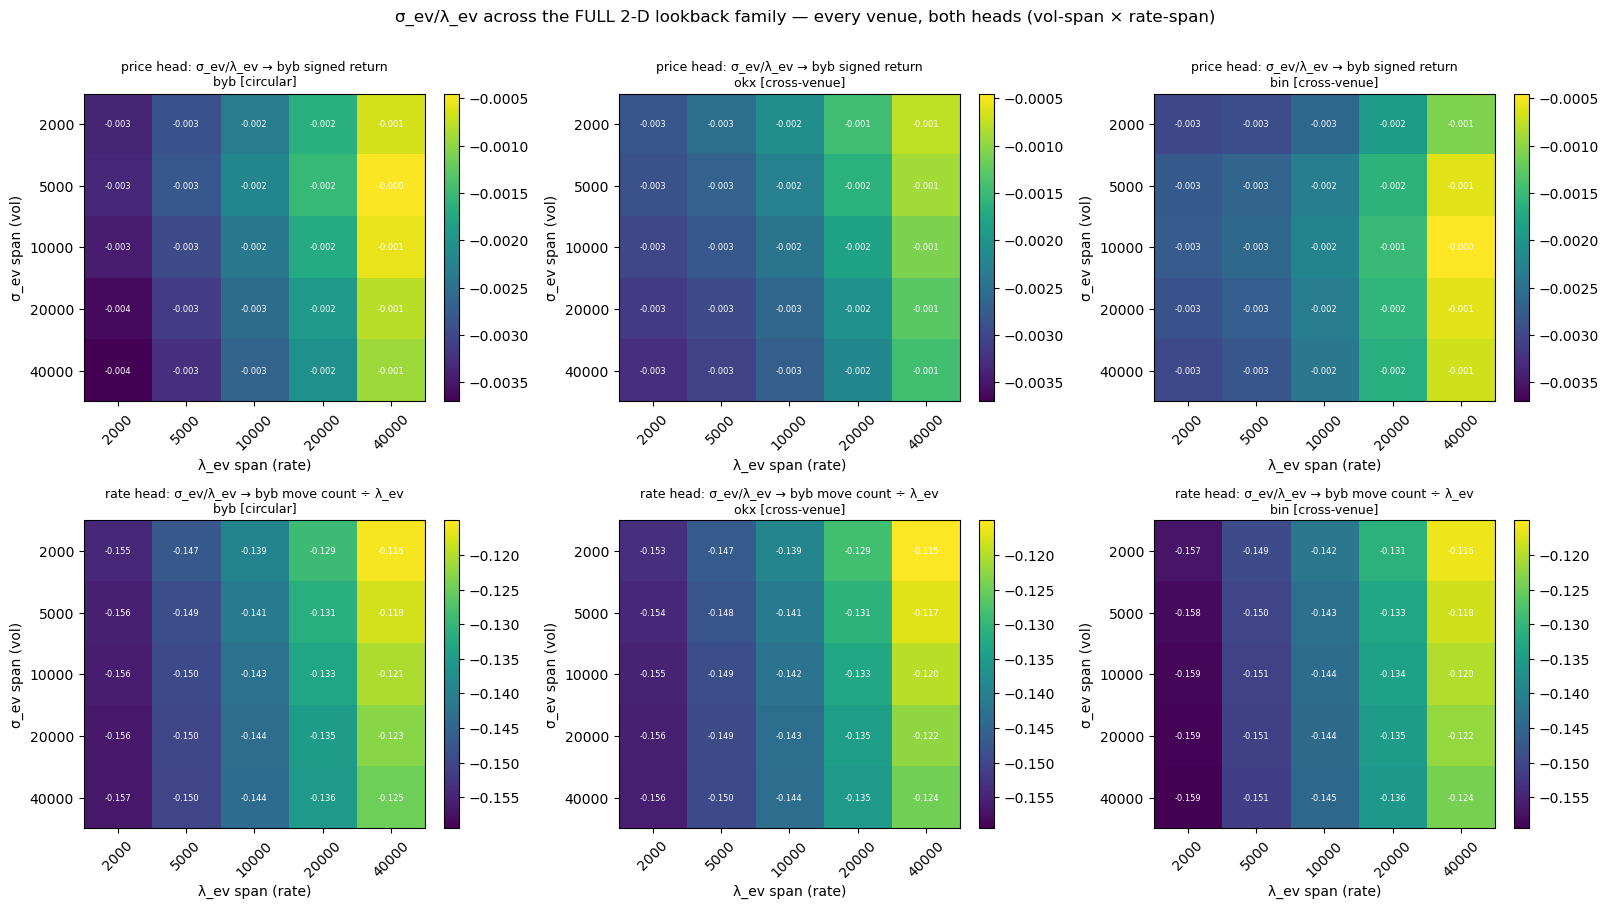

strongest cell per venue (|standalone IC|), off the FULL 2-D grid:
  byb:  rate head (vol=40000, rate=2000) IC=-0.157   |  price head (vol=40000, rate=2000) IC=-0.004
  okx:  rate head (vol=40000, rate=2000) IC=-0.156   |  price head (vol=40000, rate=2000) IC=-0.003
  bin:  rate head (vol=40000, rate=2000) IC=-0.159   |  price head (vol=2000, rate=2000) IC=-0.003


In [5]:
# rate-head target = BYB moves (on the trade clock) in the next 100 ms, divided by BYB's λ_ev (every leg predicts byb).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ byb λ_ev ∝ "more/fewer byb moves than usual" (carries units of seconds; the constant horizon factor drops out of the rank correlation)

# Sweep the FULL 2-D family (σ_ev span × λ_ev span), for EVERY venue, BOTH heads. Standalone (uncontrolled) rank-IC — picks a cell.
# price_grid: signed feature (unsigned magnitude) -> byb signed return (expect ≈0).  rate_grid: feature -> byb move count ÷ λ_ev.
price_grid = {ex: np.full((len(VOL_SPANS), len(RATE_SPANS)), np.nan) for ex in EXCHANGES}
rate_grid  = {ex: np.full((len(VOL_SPANS), len(RATE_SPANS)), np.nan) for ex in EXCHANGES}
feat_cache = {}
for ex in EXCHANGES:
    for i, vs in enumerate(VOL_SPANS):
        for j, rs in enumerate(RATE_SPANS):
            d = vol_over_rate(ex, vs, rs); feat_cache[(ex, vs, rs)] = d
            m = np.isfinite(d)
            price_grid[ex][i, j] = spearmanr(d[m], target[m]).statistic
            rate_grid[ex][i, j]  = spearmanr(d[m], rate_target[m]).statistic

fig, axes = plt.subplots(2, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 9.0), squeeze=False)
for row, (grids, head) in enumerate([(price_grid, "price head: σ_ev/λ_ev → byb signed return"),
                                     (rate_grid,  "rate head: σ_ev/λ_ev → byb move count ÷ λ_ev")]):
    allv = np.concatenate([grids[ex].ravel() for ex in EXCHANGES]); vmin, vmax = np.nanmin(allv), np.nanmax(allv)
    for col, ex in enumerate(EXCHANGES):
        ax = axes[row][col]; grid = grids[ex]; im = ax.imshow(grid, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
        ax.set_xticks(range(len(RATE_SPANS))); ax.set_xticklabels(RATE_SPANS, rotation=45); ax.set_xlabel("λ_ev span (rate)")
        ax.set_yticks(range(len(VOL_SPANS))); ax.set_yticklabels(VOL_SPANS); ax.set_ylabel("σ_ev span (vol)")
        circ = " [circular]" if ex == "byb" else " [cross-venue]"
        ax.set_title(f"{head}\n{ex}{circ}", fontsize=9)
        for i in range(len(VOL_SPANS)):
            for j in range(len(RATE_SPANS)):
                if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=6)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("σ_ev/λ_ev across the FULL 2-D lookback family — every venue, both heads (vol-span × rate-span)", y=1.005)
fig.tight_layout(); plt.show()

# pick the best cell PER VENUE, PER HEAD off the grid (in-sample pick; re-scored OOS / decoupled in the gate below)
def best_cell(grid): return np.unravel_index(np.nanargmax(np.abs(grid)), grid.shape)
price_member = {ex: best_cell(price_grid[ex]) for ex in EXCHANGES}
rate_member  = {ex: best_cell(rate_grid[ex])  for ex in EXCHANGES}
print("strongest cell per venue (|standalone IC|), off the FULL 2-D grid:")
for ex in EXCHANGES:
    ri, rj = rate_member[ex]; pi, pj = price_member[ex]
    print(f"  {ex}:  rate head (vol={VOL_SPANS[ri]}, rate={RATE_SPANS[rj]}) IC={rate_grid[ex][ri,rj]:+.3f}"
          f"   |  price head (vol={VOL_SPANS[pi]}, rate={RATE_SPANS[pj]}) IC={price_grid[ex][pi,pj]:+.3f}")

**Reading the heat-maps.** The **price head** (top) is ≈0 for every venue at every cell — correct:
`σ_ev/λ_ev` is an unsigned magnitude, so it cannot say *which way* byb moves (the in-sample picks just
land on the noisiest cell). The **rate head** (bottom) is where the structure lives: the standalone IC
against byb's move-count is non-zero and peaks at the printed cell, **for each venue** — including okx
and bin, whose pace tracks byb's forward move-count. We keep every venue and let the model weight
whichever leads.

> But the IC-max cell is only the *first* span — the next cell re-scores the whole family **conditional**
> on it (`partial-IC(cell | chosen)`) and runs the out-of-sample joint-vs-solo test to decide **whether a
> second time-scale adds** anything orthogonal, per head.

does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  byb: best alt (vol=10000,rate=40000) IC|best +0.003;  OOS joint -0.005 vs solo -0.005 (Δ+0.000)  ->  one span suffices (no OOS gain)


  okx: best alt (vol=10000,rate=2000) IC|best +0.002;  OOS joint -0.002 vs solo -0.004 (Δ+0.001)  ->  one span suffices (no OOS gain)


  bin: best alt (vol=10000,rate=40000) IC|best +0.002;  OOS joint -0.002 vs solo -0.005 (Δ+0.003)  ->  one span suffices (no OOS gain)
does a 2nd span add over the pick? — rate head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  byb: best alt (vol=40000,rate=40000) IC|best -0.010;  OOS joint +0.044 vs solo +0.121 (Δ-0.077)  ->  one span suffices (no OOS gain)


  okx: best alt (vol=40000,rate=20000) IC|best -0.013;  OOS joint +0.028 vs solo +0.119 (Δ-0.091)  ->  one span suffices (no OOS gain)


  bin: best alt (vol=2000,rate=20000) IC|best -0.013;  OOS joint +0.067 vs solo +0.125 (Δ-0.058)  ->  one span suffices (no OOS gain)


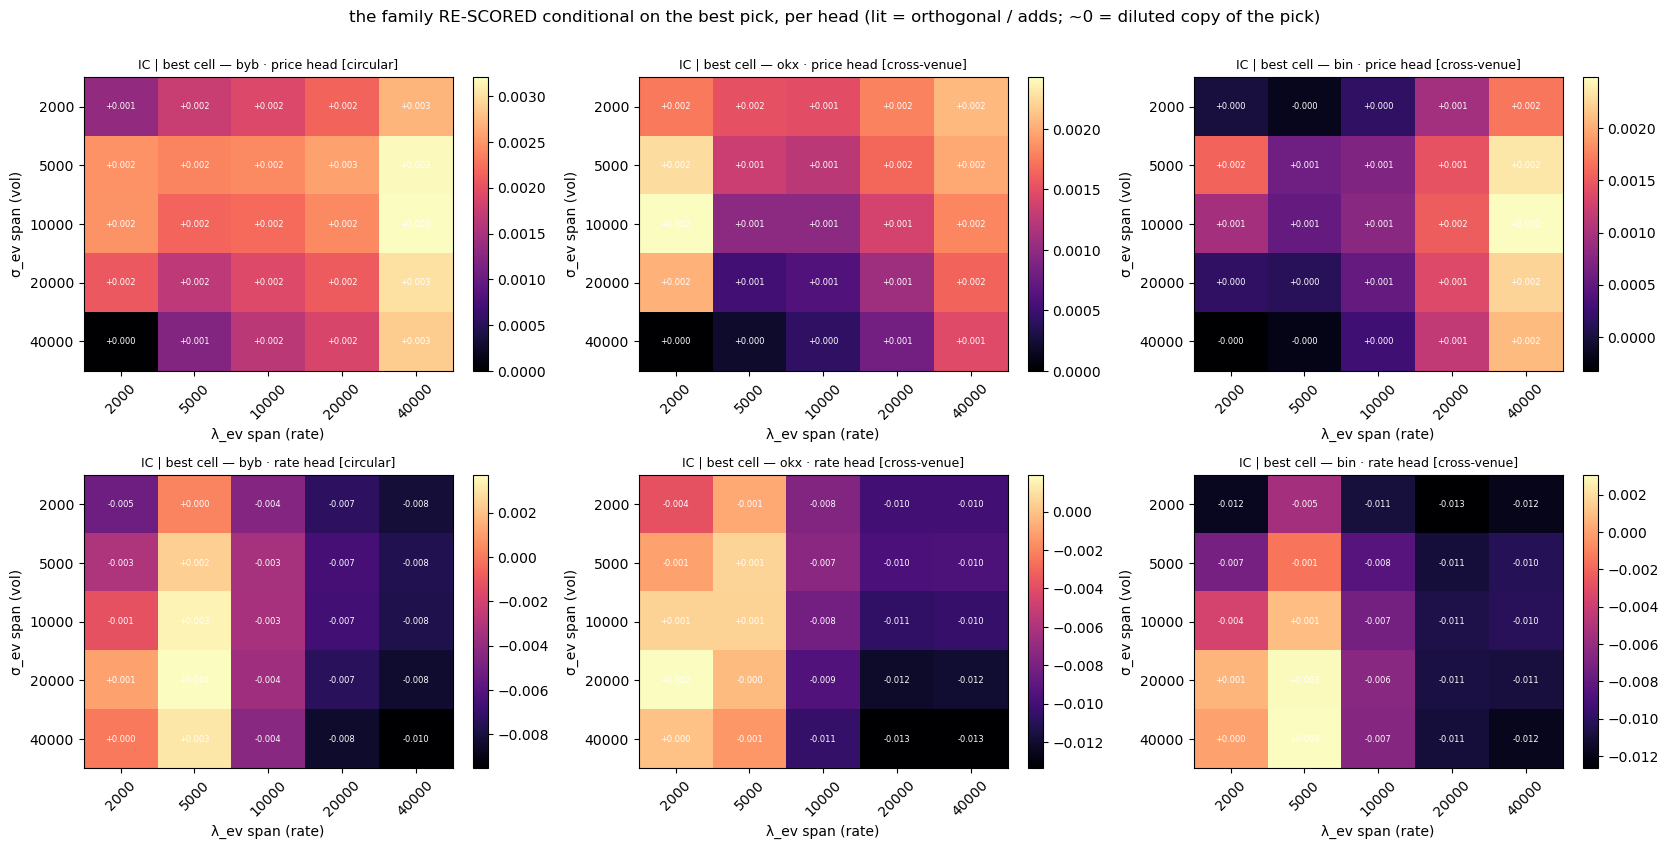

In [6]:
# === Does a SECOND time-scale ADD over the pick? — the FULL 2-D family RE-SCORED conditional on the best cell, PER HEAD ===
# Selection lives here in §6. We picked the best (vol,rate) cell per head by IC; now re-score the WHOLE 2-D family as
# partial-IC(cell | chosen) -- each cell's IC against the head's target, CONTROLLING for the cell we picked (the
# same partial-IC tool the echo-netting cell uses; control = the chosen cell's feature, not the trailing move).
# A cell still LIT adds signal ORTHOGONAL to the pick; a cell that COLLAPSES to ~0 is a diluted copy. The heat-map
# is in-sample, so the keep/drop DECISION is the walk-forward joint-vs-solo OOS IC (wf_ic, imported in §5).
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# Per head: feat() maps a (vol,rate) cell to its scored feature, tgt is the head's target, member is the in-sample pick.
HEADS = [("price head", lambda ex, vs, rs: vol_over_rate(ex, vs, rs),         target,      price_member),
         ("rate head",  lambda ex, vs, rs: np.abs(vol_over_rate(ex, vs, rs)), rate_target, rate_member)]
fig, axes = plt.subplots(len(HEADS), len(EXCHANGES), figsize=(5.6 * len(EXCHANGES), 4.2 * len(HEADS)), squeeze=False)
second = {}
for row, (head, feat, tgt, member) in enumerate(HEADS):
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    for col, ex in enumerate(EXCHANGES):
        ci, cj = member[ex]; chosen = feat(ex, VOL_SPANS[ci], RATE_SPANS[cj])
        cond = np.full((len(VOL_SPANS), len(RATE_SPANS)), np.nan)
        for i, vs in enumerate(VOL_SPANS):
            for j, rs in enumerate(RATE_SPANS):
                cond[i, j] = 0.0 if (i, j) == (ci, cj) else _pic(feat(ex, vs, rs), tgt, chosen)
        ax = axes[row][col]; im = ax.imshow(cond, cmap="magma", aspect="auto")
        ax.set_xticks(range(len(RATE_SPANS))); ax.set_xticklabels(RATE_SPANS, rotation=45); ax.set_xlabel("λ_ev span (rate)")
        ax.set_yticks(range(len(VOL_SPANS))); ax.set_yticklabels(VOL_SPANS); ax.set_ylabel("σ_ev span (vol)")
        circ = " [circular]" if ex == "byb" else " [cross-venue]"
        ax.set_title(f"IC | best cell — {ex} · {head}{circ}", fontsize=9)
        for i in range(len(VOL_SPANS)):
            for j in range(len(RATE_SPANS)):
                if np.isfinite(cond[i, j]): ax.text(j, i, f"{cond[i, j]:+.3f}", ha="center", va="center", color="w", fontsize=6)
        fig.colorbar(im, ax=ax, fraction=0.046)
        bi, bj = np.unravel_index(np.nanargmax(np.abs(cond)), cond.shape)          # the most-orthogonal alternative cell (in-sample screen)
        f1, f2 = chosen, feat(ex, VOL_SPANS[bi], RATE_SPANS[bj])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)                       # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                                        # the OOS joint gain DECIDES
        second[(head, ex)] = (bi, bj) if keep else None
        print(f"  {ex}: best alt (vol={VOL_SPANS[bi]},rate={RATE_SPANS[bj]}) IC|best {cond[bi, bj]:+.3f};  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
fig.suptitle("the family RE-SCORED conditional on the best pick, per head (lit = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.005)
fig.tight_layout(); plt.show()

**Does a *second* time-scale add — per head?** The IC heat-map picks the best (vol, rate) cell per head; a
second cell is only worth feeding if it carries signal the first doesn't. We test that by **re-scoring the
whole 2-D family conditional on the chosen pick** — each cell's IC recomputed as `partial-IC(cell | chosen)`:
its predictive power against the head's target **controlling for the cell we already picked** (the same
partial-IC tool the echo-netting cell uses; control = the chosen cell's feature). A cell that stays **lit** is
**orthogonal** — it adds new signal — while a cell that **collapses to ≈ 0** is a diluted copy of the pick.
Because that heat-map is **in-sample**, the keep/drop **decision** is the overfitting-resistant **walk-forward
joint-vs-solo** IC (`wf_ic([chosen, alt]) − wf_ic([chosen])`): keep the second cell only when the out-of-sample
gain clears the ~0.01 floor. We run it for **both heads** (price → signed feature vs the σ-return target; rate →
|feature| vs the count target), and the two heads fail to keep a second cell for **different reasons** on this
block. For the **price head** the second cell is a genuine **diluted copy**: it adds nothing (OOS joint-vs-solo
gain ≈ 0 — Δ ≈ +0.000 / +0.001 / +0.003 for byb / okx / bin, both joint and solo near 0 because an unsigned
feature has no directional edge). For the **rate head** the second cell is not a near-zero copy at all — adding
it markedly **degrades** OOS IC: the walk-forward joint sits well *below* the solo (joint +0.044 vs solo +0.121
byb, Δ-0.077; +0.028 vs +0.119 okx, Δ-0.091; +0.067 vs +0.125 bin, Δ-0.058 — the conditional cells even read
slightly negative in-sample). Either way the decision is the same — **one (vol, rate) cell per head suffices** —
but on the rate head it is because the second cell *hurts* out-of-sample, not because it is a near-zero copy.

In [7]:
# --- the gate table: a CONTROL feature. byb's OWN leg is judged STANDALONE (marginal-over-its-own-controls is circular);
#     the okx/bin CROSS-venue legs are judged MARGINAL over byb's controls (a genuine lead test). All scored vs the RATE-head
#     count target (the feature's natural head) at each venue's best rate-head cell. ---
chosen = {ex: feat_cache[(ex, VOL_SPANS[rate_member[ex][0]], RATE_SPANS[rate_member[ex][1]])] for ex in EXCHANGES}  # each venue at its best rate-head cell
# byb own leg — STANDALONE stratified IC (own=True): marginal-over-byb's-controls is circular, and the feature & rate target
# share the 1/λ_ev denominator, so score WITHIN λ_ev strata (STRAT_VAR) to decouple it.
byb_standalone = signal_ic([chosen["byb"]], own=True, tgt=rate_target)
# okx/bin CROSS-venue legs — MARGINAL over byb's controls (own=False): does another venue's pace LEAD byb's count?
cross_legs = [chosen[ex] for ex in EXCHANGES if ex != "byb"]
joint_cross = signal_ic(cross_legs, own=False, tgt=rate_target)        # okx+bin together, marginal over byb's controls
strat_cross = signal_ic_by_regime(cross_legs, own=False, tgt=rate_target)  # the calm/mid/wild companion (cross-venue marginal)
cci = wf_marginal_ci(cross_legs, rate_target)                          # H5: per-fold spread + block-bootstrap CI for the cross-venue marginal
print(f"byb STANDALONE (rate, within-λ_ev strata) {byb_standalone:+.3f}  |  okx+bin CROSS-venue marginal {joint_cross:+.3f}"
      f"  per-fold {cci['per_fold']} (+ in {cci['pos']}/{cci['nf']})  block-bootstrap 90% CI [{cci['ci'][0]}, {cci['ci'][1]}]  (block ~{cci['block_len']} anchors ~{cci['block_s']}s)")
rep = chosen[EXCHANGES[0]]                              # byb leg — for the momenta-overlap sanity print only (Gate A runs PER EXCHANGE below)
# GATE A — regime invariance (vol_level/rate_level are the regime COORDINATE, never controls), run PER EXCHANGE
# (Gate A is a property of the output DISTRIBUTION, which differs by venue — bin is sub-ms fresh, byb/okx stale):
# scale, plus the signed feature AND its magnitude |feature| (which the signed-fed rate head can learn), each checked
# two ways x two coordinates — TRACK = |IC(., vol/rate level)| (monotone drift) and DISP = per-decile-mean dispersion
# vs vol OR rate (a NON-monotone leak the monotone IC misses); each row reports the WORST coordinate.
# LOW-1 sanity: a "control" SHOULD overlap the momenta (it IS a regime descriptor) — large is expected here, the opposite of an alpha.
print(f"FEATURE_KIND={FEATURE_KIND!r} | byb feature vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (a control IS a regime descriptor, so some overlap is expected)")
gate_rows  = [dict(gate="B · signal (standalone)", detail="byb own leg — STANDALONE rate IC within λ_ev strata (circular-with-controls -> standalone)", value=byb_standalone)]
gate_rows += [dict(gate="B · signal (standalone)", detail=f"{ex} own leg — STANDALONE rate IC within λ_ev strata",
                   value=signal_ic([chosen[ex]], own=True, tgt=rate_target)) for ex in EXCHANGES if ex != "byb"]
gate_rows += [dict(gate="B · lead (cross-venue)", detail="okx+bin together — MARGINAL rate-count IC over byb's controls (does another venue lead byb?)", value=joint_cross)]
gate_rows += [dict(gate="B · lead (cross-venue)", detail=f"{ex} alone — MARGINAL rate-count IC over byb's controls",
                   value=signal_ic([chosen[ex]], own=False, tgt=rate_target)) for ex in EXCHANGES if ex != "byb"]
# coupling confirmation: the standalone IC WITHIN λ_ev strata decouples the shared 1/λ_ev; show the raw (un-stratified) standalone IC alongside.
gate_rows += [dict(gate="B · coupling", detail=f"{ex} — raw standalone rate IC, UN-stratified (vs the stratified line => shows the 1/λ_ev decouple)",
                   value=round(ic(chosen[ex], rate_target), 3)) for ex in EXCHANGES]
for ex in EXCHANGES:                                    # GATE A PER EXCHANGE (worst coordinate per check) — every venue, the distribution differs by venue
    a = gate_a(chosen[ex])
    gate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate head can learn it), worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
gate_rows += [dict(gate="regime-stable (cross-venue)", detail=f"okx+bin marginal within {nm}-vol (companion: stay positive)", value=strat_cross.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(40); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(gate_rows)

byb STANDALONE (rate, within-λ_ev strata) -0.060  |  okx+bin CROSS-venue marginal +0.002  per-fold [-0.001, -0.002, -0.0, 0.004, 0.009] (+ in 2/5)  block-bootstrap 90% CI [-0.002, 0.004]  (block ~9083 anchors ~454.2s)


FEATURE_KIND='control' | byb feature vs momenta |IC|: rate 0.378 vol 0.070  (a control IS a regime descriptor, so some overlap is expected)


gate,detail,value
str,str,f64
"""B · signal (standalone)""","""byb own leg — STANDALONE rate IC within λ_ev strata (circular-with-con…",-0.06
"""B · signal (standalone)""","""okx own leg — STANDALONE rate IC within λ_ev strata""",-0.06
"""B · signal (standalone)""","""bin own leg — STANDALONE rate IC within λ_ev strata""",-0.069
"""B · lead (cross-venue)""","""okx+bin together — MARGINAL rate-count IC over byb's controls (does an…",0.002
"""B · lead (cross-venue)""","""okx alone — MARGINAL rate-count IC over byb's controls""",-0.007
"""B · lead (cross-venue)""","""bin alone — MARGINAL rate-count IC over byb's controls""",-0.001
"""B · coupling""","""byb — raw standalone rate IC, UN-stratified (vs the stratified line =>…",-0.157
"""B · coupling""","""okx — raw standalone rate IC, UN-stratified (vs the stratified line =>…",-0.156
"""B · coupling""","""bin — raw standalone rate IC, UN-stratified (vs the stratified line =>…",-0.159


**Conclusion (read honestly — this is a control).** `vol_over_rate` is a regime descriptor, so its
gate is read with the circularity caveat:

- **Standalone signal (the control's real test).** byb's `σ_ev/λ_ev` carries a real **standalone**
  rate-head signal — its within-λ_ev-strata IC against the count target is the printed value above, and
  it stays well clear of zero, confirming the feature describes a genuine texture of byb's next 100 ms.
  The raw (un-stratified) standalone IC is larger; the **stratified** number is the honest one (it
  removes the shared `1/λ_ev` arithmetic), and the gap between them is exactly the spurious-ratio
  coupling the stratify decouples. The okx/bin own-leg standalone numbers are the same texture read from
  another venue.
- **Cross-venue lead (the non-circular marginal).** The okx+bin **marginal** over byb's controls is the
  honest answer to *"does another venue's pace lead byb?"* — **≈0 here** (+0.002, 90% CI [−0.002, 0.004],
  positive in only 2/5 folds, as the printed joint marginal/CI show): the venues' paces are tightly coupled
  at this 100 ms horizon, so most of the rate-regime information is already in byb's own controls. §9 sweeps
  the span family and finds this marginal **≈0-to-negative at every lookback** (most negative at the short
  end), so there is **no** cross-venue lead at any span on this block — §1's cross-venue disproof condition
  is met, and byb's own leg suffices across the family.
- **Gate A (regime invariance) FAILS hard per venue — this feature TRACKS the regime.** Only **one** of the
  four Gate-A checks passes: **scale** (printed max/min ≈ 1.76 / 2.34 / 1.31 for byb/okx/bin, all < ~3 — the
  feature's std is stable across vol buckets). The other three FAIL by ~8–18×: the signed-feature **track**
  `|IC(feature, vol/rate level)|` ≈ 0.894 / 0.841 / 0.842 (HARD bar ~0.05), the **magnitude track** ≈ 0.894 /
  0.841 / 0.842 (bar ~0.1), and the non-monotone **dispersion** ≈ 0.836 / 0.772 / 0.795 (bar ~0.1). Per the
  project's own rule (*never call a feature regime-invariant until **every** Gate-A number says so*), this is a
  clean FAIL: `σ_ev/λ_ev` strongly **tracks** the regime and is **not** a regime-invariant coordinate. That is
  exactly what we expect for a *control that is an exact linear combination of the vol/rate levels*
  (`log(σ_ev/λ_ev) = vol_level − rate_level`) — it co-moves with the levels almost perfectly, so its mean
  shifts with the regime even though its spread (scale) is roughly fixed. (The large overlap with the momenta —
  rate |IC| 0.378 — is the same story, and the opposite of an alpha, confirming `FEATURE_KIND="control"`.)

Verdict: byb's `σ_ev/λ_ev` is a **regime-tracking rate coordinate**, not a regime-invariant one — its level
moves with the vol/rate regime (Gate A fails the track/mag/dispersion checks by ~8–18×; only its scale is
stable). It is still credited as a **control** by its **standalone** signal, not by a marginal over its own
controls; the cross-venue legs are honest predictors whose marginal value over byb's own reading is small at
this horizon (see §9 for the span dependence). The **price head** is the ≈0 directional diagnostic (an
unsigned feature has no direction).

## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a positive forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor-100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.)

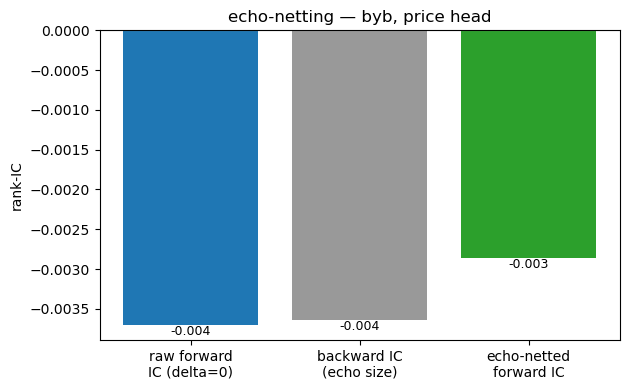

raw forward IC -0.004;  backward (echo) IC -0.004;  echo-netted forward IC -0.003  (the raw->netted shortfall is echo)


In [8]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
rep_ex = EXCHANGES[0]                                   # one exchange to illustrate; every feature carries its own
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                         # byb merged mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_mid_at(t1) / _mid_at(t0))
def _partial_ic(f, y, t):                               # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

signed = vol_over_rate(rep_ex, VOL_SPANS[price_member[rep_ex][0]], RATE_SPANS[price_member[rep_ex][1]])   # the chosen price-head feature
_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
raw_ic   = _ic(signed, _fwd0)                             # raw forward IC
back_ic  = _ic(signed, _trail)                            # backward IC — sizes the contemporaneous echo
echo_net = _partial_ic(signed, _fwd0, _trail)             # forward IC NETTED of the echo (controls for the trailing move)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
labels = ["raw forward\nIC (delta=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
vals = [raw_ic, back_ic, echo_net]
bars = ax.bar(labels, vals, color=["C0", "0.6", "C2"])
ax.axhline(0, color="0.7", lw=0.8); ax.set_ylabel("rank-IC"); ax.set_title(f"echo-netting — {rep_ex}, price head")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
fig.tight_layout(); plt.show()
print(f"raw forward IC {raw_ic:+.3f};  backward (echo) IC {back_ic:+.3f};  echo-netted forward IC {echo_net:+.3f}  (the raw->netted shortfall is echo)")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor-100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.)

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when okx's book moves before byb's reflects it
(byb/okx top-of-book is stale p90 ~100-160 ms vs bin's sub-ms), that lead is **genuine and exploitable**, and
the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do **not** coarsen the
foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be fake if the
recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here, where the
recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by the feature
and look at the real distributions the two heads care about. Because `vol_over_rate` is an unsigned
**intensity** feature, the rate-head panel is the one that should move; the price-head panel is shown for
completeness (and should be roughly flat — no directional tilt). We show **byb's own leg** here (the model's
native coordinate); the cross-venue shape is similar in kind.

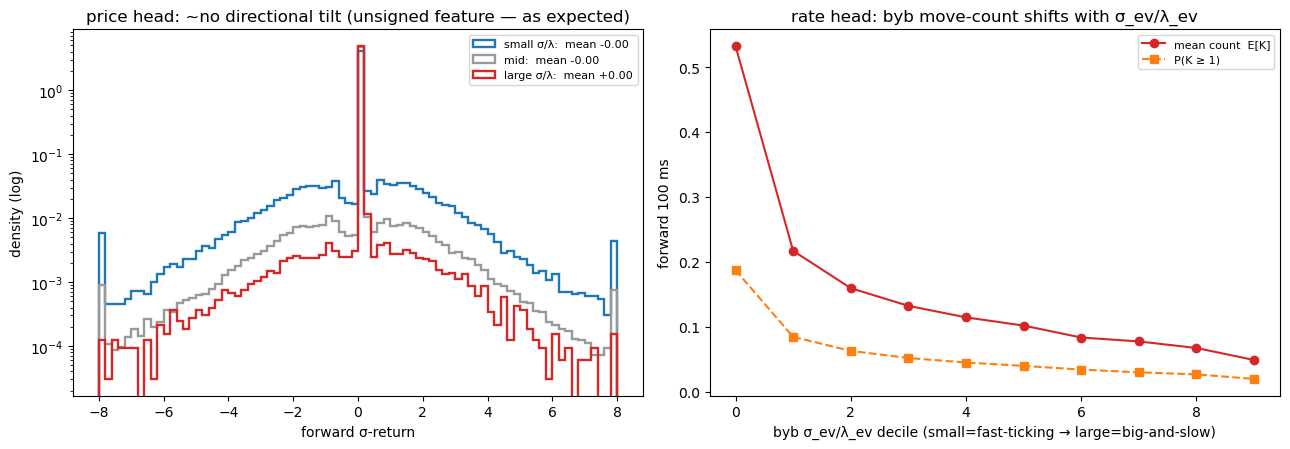

In [9]:
f = chosen["byb"]                                                               # byb's feature at its best rate-head cell
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across feature buckets — expect NO directional tilt (unsigned feature)
lo, hi = np.nanpercentile(f, [10, 90])
groups = [("small σ/λ", f <= lo, "C0"), ("mid", (f > lo) & (f < hi), "0.6"), ("large σ/λ", f >= hi, "C3")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    mm = m & np.isfinite(target)
    axA.hist(np.clip(target[mm], -8, 8), bins=bins, density=True, histtype="step", color=col, lw=1.7,
             label=f"{lab}:  mean {np.nanmean(target[mm]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title("price head: ~no directional tilt (unsigned feature — as expected)"); axA.legend(fontsize=8)

# rate head: forward move-count vs feature decile — the natural home; expect a monotone trend
# raw fwd_count is shown here only for intuition; the rate head's actual target is rate_target = fwd_count / λ_ev (count ÷ λ_ev)
dec = np.digitize(f, np.nanpercentile(f[np.isfinite(f)], np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("byb σ_ev/λ_ev decile (small=fast-ticking → large=big-and-slow)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: byb move-count shifts with σ_ev/λ_ev"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The price-head panel is flat — the forward-return distribution barely shifts across
small/mid/large `σ_ev/λ_ev` (the group means in the legend are all ≈0), confirming the feature carries **no
direction** (it is unsigned). The rate-head panel is where the structure lives: the forward move-count `E[K]`
and `P(K ≥ 1)` change monotonically across `σ_ev/λ_ev` deciles — read the slope/sign off the printed curve.
So the feature does describe a real texture of the next 100 ms — but, per §6, for the byb leg it describes the
*same* texture the vol/rate controls already encode; its value is as a **pre-combined, interpretable
coordinate**, credited by its standalone signal, not as orthogonal marginal signal.

## 8. Input shaping for the network

This is a *different* step from §2. There we noted the feature needs no further regime-division (it is
already a ratio). Here we reshape the feature for the neural network's input — roughly centred, unit-scale,
no wild outliers. `σ_ev/λ_ev` is a positive, right-skewed quantity (a ratio of positives, in seconds), so we
expect a log or rank transform to help more than a plain z-score. Pick the **lightest** transform that does
the job; the QQ-plot makes the choice. (Shown for byb's leg; the cross-venue legs are the same positive-ratio
shape.)

feature (raw): skew=+1.78  excess_kurt=6.9   |   log: skew=-0.82  excess_kurt=1.5  (0 = normal)
  z-score (raw)          excess_kurt=   6.9   max|·|=8.5
  log                    excess_kurt=   1.5   max|·|=5.8
  log robust + clip ±4   excess_kurt=   0.9   max|·|=4.0
  rank-Gaussian          excess_kurt=  -0.0   max|·|=5.0


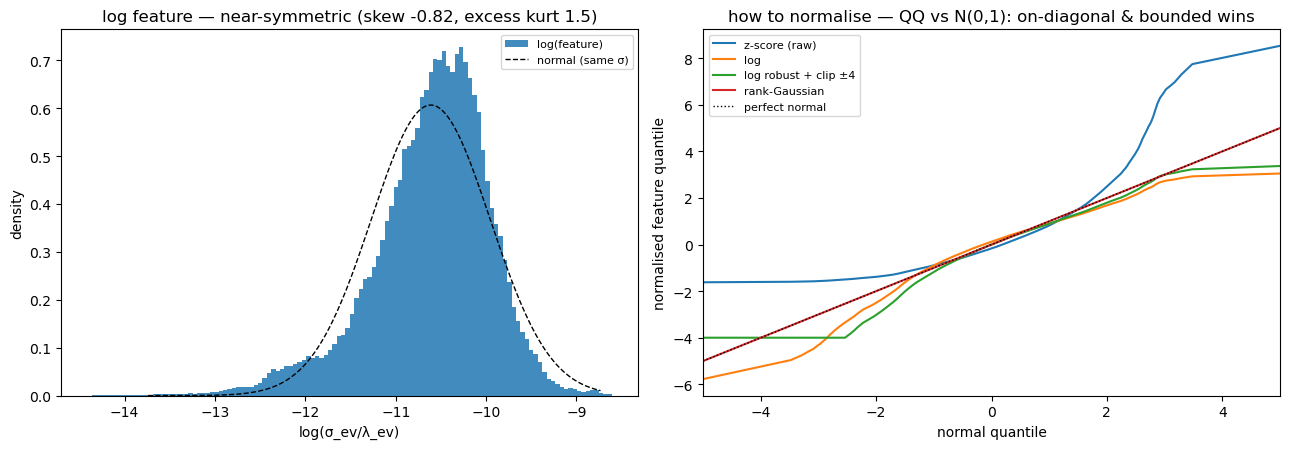

In [10]:
from scipy.stats import skew, kurtosis, rankdata, norm
f = chosen["byb"]; f = f[np.isfinite(f) & (f > 0)]
lf = np.log(f)                                                          # the feature is positive & right-skewed -> log is the natural first move
med = np.median(lf); mad = 1.4826 * np.median(np.abs(lf - med)) + 1e-12; rz = (lf - med) / mad
cand = {"z-score (raw)": (f - f.mean()) / (f.std() + 1e-12),
        "log": (lf - lf.mean()) / (lf.std() + 1e-12),
        "log robust + clip ±4": np.clip(rz, -4, 4),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature (raw): skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}   |   log: skew={skew(lf):+.2f}  excess_kurt={kurtosis(lf):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:22} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(lf, bins=120, density=True, color="C0", alpha=.85, label="log(feature)")
xg = np.linspace(np.percentile(lf, 0.05), np.percentile(lf, 99.95), 300)
axA.plot(xg, norm.pdf(xg, lf.mean(), lf.std()), "k--", lw=1, label="normal (same σ)")
axA.set_xlabel("log(σ_ev/λ_ev)"); axA.set_ylabel("density")
axA.set_title(f"log feature — near-symmetric (skew {skew(lf):+.2f}, excess kurt {kurtosis(lf):.1f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout settles it. The raw feature is positive and right-skewed (a ratio in seconds —
read the raw skew/excess-kurt above), so a plain z-score leaves a long right tail with a large `max|·|`.
Taking `log` first — the natural move for a positive ratio — pulls the skew toward 0 and tames the tails; a
robust-z then a clip ±4 bounds the rare outliers to `max|·| = 4`. So the **lightest** transform that meets
the "no wild outliers" bar is **log → robust-z → clip ±4** (the rank-Gaussian flattens further but throws
information away). Feed `log(σ_ev/λ_ev)`, standardised and clipped — which, for byb, is literally
`vol_level − rate_level` up to scale. The cross-venue legs take the same transform.

**Still to run** (same machinery): whether the feature adds over features we already have; whether the signal
is steady day-to-day; and whether it survives out-of-sample across a market-regime change. (The leak check
*inside* volatility buckets is no longer pending — Gate A's checks and the regime-stable companion now run it.)

## 9. When is per-exchange worth it? (for poolable features)

Unlike the template's gap (a quantity *between* two exchanges), `vol_over_rate` is a genuine **per-exchange**
number — so the pool / single / per-exchange choice is real here. The answer depends on the time-scale, so
sweep it and compare the three:
- **pooled** — one `σ_ev/λ_ev` over *all* venues' mid-moves on the shared clock (E and W summed across venues
  before the ratio);
- **best single** — the single most predictive venue's `σ_ev/λ_ev` (in-sample pick, scored OOS);
- **per-exchange** — all three legs fed in together.

The cross-venue edge is a **lead/lag** — one venue shifting its texture a beat before another — that lives
at **short** spans (a fast yardstick reacts within the lead window); at **long** spans every venue's slow
yardstick averages over the same regime, so the legs converge and byb's own carries it. So we expect:
**short lookback → per-exchange / pooled carry distinct value; long lookback → they converge, one (byb)
suffices.** We score each by **marginal walk-forward** rank-IC over byb's controls (against byb's rate-count
target), at a short, a medium, and a long span (shared `σ_ev=λ_ev` span at each point, since the lead/lag axis
is the overall memory).

shape: (3, 4)
┌──────────────────┬────────┬──────────────┬──────────────┐
│ time_scale       ┆ pooled ┆ best_single  ┆ per_exchange │
│ ---              ┆ ---    ┆ ---          ┆ ---          │
│ str              ┆ f64    ┆ str          ┆ f64          │
╞══════════════════╪════════╪══════════════╪══════════════╡
│ short (N=2000)   ┆ -0.008 ┆ 0.001 (bin)  ┆ -0.009       │
│ medium (N=10000) ┆ -0.007 ┆ -0.005 (bin) ┆ -0.008       │
│ long (N=40000)   ┆ -0.005 ┆ -0.004 (okx) ┆ -0.006       │
└──────────────────┴────────┴──────────────┴──────────────┘


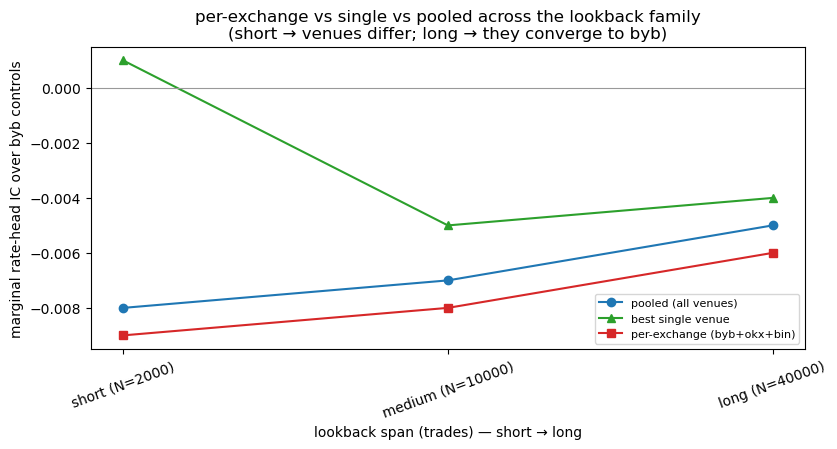

In [11]:
# pooled σ_ev/λ_ev: sum E (Σ r²) and W (move count) across ALL venues per anchor, plus the SHARED seconds-per-trade leg, then the ratio.
def pooled_vol_over_rate(N):
    e_sq = sum(_flow_at(ex, anchor_ts, MS[ex]["mv_r2"], N) for ex in EXCHANGES)               # pooled E: Σ r² over every venue's moves
    e_mv = sum(_flow_at(ex, anchor_ts, np.ones(MS[ex]["mv_r2"].size), N) for ex in EXCHANGES) # pooled W: total move count over every venue
    e_dt = _ewma(byb_dt, N)[np.searchsorted(merged_ts, anchor_ts, "right") - 1]               # seconds/trade on the SHARED clock
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                                             # pooled σ_ev: RMS move per move, all venues
    lam = e_mv / np.maximum(e_dt, 1e-12)                                                      # pooled λ_ev: pooled moves per second
    return sig / np.maximum(lam, 1e-12)

scan = [("short", 2000), ("medium", 10000), ("long", 40000)]   # short / medium / long shared spans (within the swept family)
rows = []
for label, N in scan:
    per_ex = [vol_over_rate(ex, N, N) for ex in EXCHANGES]
    single_ic = {ex: wf_ic(base + [vol_over_rate(ex, N, N)], rate_target) - wf_ic(base, rate_target) for ex in EXCHANGES}
    best_ex = max(single_ic, key=single_ic.get)
    pooled  = round(wf_ic(base + [pooled_vol_over_rate(N)], rate_target) - wf_ic(base, rate_target), 3)
    single  = round(single_ic[best_ex], 3)
    perex   = round(wf_ic(base + per_ex, rate_target) - wf_ic(base, rate_target), 3)
    rows.append(dict(time_scale=f"{label} (N={N})", pooled=pooled, best_single=f"{single} ({best_ex})", per_exchange=perex))
tbl = pl.DataFrame(rows)
print(tbl)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
x = range(len(scan))
ax.plot(x, [r["pooled"] for r in rows], "o-", color="C0", label="pooled (all venues)")
ax.plot(x, [float(r["best_single"].split()[0]) for r in rows], "^-", color="C2", label="best single venue")
ax.plot(x, [r["per_exchange"] for r in rows], "s-", color="C3", label="per-exchange (byb+okx+bin)")
ax.axhline(0, color="0.6", lw=0.8); ax.set_xticks(list(x)); ax.set_xticklabels([r["time_scale"] for r in rows], rotation=20)
ax.set_xlabel("lookback span (trades) — short → long"); ax.set_ylabel("marginal rate-head IC over byb controls")
ax.set_title("per-exchange vs single vs pooled across the lookback family\n(short → venues differ; long → they converge to byb)")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

**Conclusion (the per-exchange verdict — read honestly, this block does NOT show a short-span lead).**
Marginal walk-forward rank-IC over byb's controls for **pooled** vs **best single** vs **per-exchange**, at a
short / medium / long span (against byb's rate-count target — the numbers off the table/plot above):

| span | pooled | best single | per-exchange |
|---|---|---|---|
| short (N=2000)   | **−0.008** | +0.001 (bin) | **−0.009** |
| medium (N=10000) | **−0.007** | −0.005 (bin) | **−0.008** |
| long (N=40000)   | **−0.005** | −0.004 (okx) | **−0.006** |

The template's *expected* pattern is short-span → cross-venue legs add a distinct lead, long-span → they
converge to byb. **This block does NOT exhibit that pattern.** The per-exchange (and pooled) marginal over
byb's controls is **≈0-to-negative at every span**, and — opposite to the template story — it is **most
negative at the short end** (per-exchange −0.009 short → −0.006 long; pooled −0.008 → −0.005). A *negative*
marginal means adding okx/bin **reduces** walk-forward IC versus byb's controls alone; they do **not** add
real lead/lag value anywhere, least of all at the short end. Best-single is the same story: ≈0 at short
(+0.001) and slightly negative at medium/long. This is §6's joint cross-venue marginal (+0.002, 90% CI
[−0.002, 0.004], positive in only 2/5 folds) read across the span family — i.e. **no venue leads byb's pace
at any lookback**, exactly §1's cross-venue disproof condition. So on this block **byb's own leg suffices
across the whole family**; okx/bin are redundant-to-mildly-harmful as marginal predictors at every span (the
overlap is *non-circular* — they are other venues' vol/rate, not byb's controls — it is genuinely measured to
be ≈0/negative, not assumed). Pooling is never strictly best either. The cross-venue legs are still worth
*carrying* (let the model weight them; another block may differ), but on this block the honest verdict is:
keep byb's leg; the extra venues add no marginal lead at the short end or anywhere else.

## 10. The verdict, and what it takes to ship

**Keep it — for the rate head (its natural head), at the single best (vol, rate) cell per venue. byb's own
leg suffices across the whole span family on this block — the okx/bin cross-venue legs add no marginal lead
at any lookback (§9), so byb-only is the honest default; carry the extra venues only as a hedge for blocks
that differ.**

`vol_over_rate = σ_ev / λ_ev` is a clean, O(1), parity-validated (every venue) **regime-tracking coordinate**
in physical units (seconds): large = big-and-slow moves, small = small-and-fast. It is **not** regime-invariant
— Gate A fails its track/mag/dispersion checks (§6), as expected for an exact linear combination of the
vol/rate levels. Feed `log(σ_ev/λ_ev)`
(standardised, clipped) to the **rate head**. It is a **control**, not an alpha: it is credited by its
**standalone** rate-head signal (within-λ_ev strata, §6), *not* by a marginal over its own vol/rate controls
(which is ≈0 by construction for the byb leg — `log(σ_ev/λ_ev) = vol_level − rate_level`). The **price head**
is the ≈0 directional diagnostic (an unsigned feature has no direction).

**One time-scale suffices per head (the §6 second-span finding) — for two different reasons.** The §6
conditional-IC re-scoring picks the best (vol, rate) cell per head, then asks whether a second cell adds
out-of-sample. The keep/drop verdict is **one cell per head** for both heads, but the *reason* differs. On the
**price head** the second cell really is a near-zero **diluted copy** — the walk-forward joint-vs-solo gain is
≈0 (Δ ≈ +0.000 / +0.001 / +0.003 byb / okx / bin, both legs near 0 because an unsigned feature carries no
direction). On the **rate head** the second cell is *not* a near-zero copy — adding it markedly **degrades** OOS
IC: the walk-forward joint sits well below the solo (joint +0.044 vs solo +0.121 byb, Δ-0.077; +0.028 vs +0.119
okx, Δ-0.091; +0.067 vs +0.125 bin, Δ-0.058 — all far below the ~0.01 floor, and negative deltas). So a
**second** time-scale adds nothing on the price head and actively *hurts* on the rate head; either way ship the
single best (vol, rate) cell per venue (rate head). If a future block's conditional-IC map lights up an
orthogonal second cell with a positive OOS joint gain, revisit and ship both then.

**Per-exchange (the per-exchange axis) — no cross-venue lead on this block.** Compute the feature for **every
venue** (byb, okx, bin) from that venue's own mid-moves; byb's own leg is the model's native coordinate. The
template's expected pattern is okx/bin adding a distinct lead at short lookbacks and converging to byb at
long, but **this block does not show it**: the okx/bin **cross-venue** marginal over byb's controls is
≈0-to-negative at **every** span and **most negative at the short end** (per-exchange −0.009 short → −0.006
long; §9), so the extra venues add **no** marginal lead at any lookback — §1's cross-venue disproof condition
is met here, and **byb's own leg suffices across the whole family**. Pooling is never strictly best either.
The honest policy on this block is byb-only; still build all three legs and let the model weight them (another
block may genuinely lead), but do not claim a short-span cross-venue edge — there isn't one here.

**Echo — cite the NETTED number.** The echo-netted gate is the right tool, but on this block it has nothing to
net: scored on byb's **price-head** (signed) feature — which is ≈0 by construction, since `σ_ev/λ_ev` is an
unsigned magnitude with no directional edge — the trailing-move (backward, already-happened) IC is itself ≈0
(raw forward IC -0.004, backward/echo IC -0.004, echo-netted forward IC -0.003). So there is **no large echo to
net out** here, and the directional leg is a non-signal both before and after netting — consistent with the
price head being the ≈0 directional diagnostic throughout. (Where a leg *does* carry a forward IC, cite the
**echo-netted (partial)** number — the feature vs the forward outcome *controlling for the trailing*
`[anchor−100 ms, anchor]` outcome — not the raw δ=0 IC: a raw IC that survives netting is real forward
information, one that collapses toward 0 was mostly re-reporting the move already underway.) Cross-venue
freshness leads are **genuine, exploitable edge** (the recording is production timing), not an artifact to
coarsen away.

**To ship:**
- [x] the streaming (constant-work-per-trade) builder, matching this analysis version, **every venue** —
      **§4 parity check bit-exact on a real block**
- [x] the §4 parity check, passing — and the tests
- [x] the FULL 2-D lookback family swept (σ_ev span × λ_ev span), best cell picked per head per venue
- [x] the §6 second-time-scale check: family RE-SCORED conditional on the pick (partial-IC) + OOS joint-vs-solo verdict → one (vol, rate) cell per head suffices on this block
- [x] the per-exchange-vs-single-vs-pooled analysis (§9): cross-venue marginal ≈0-to-negative at EVERY span (most negative at short) → byb alone suffices across the family on this block; pooling never best
- [x] the gate results recorded — byb judged STANDALONE (control), okx/bin cross-venue marginal honest
- [x] the **echo-netted (partial) forward IC** gate run — byb's price-head leg ≈0 with no echo to net (raw/back/netted all ≈0)
- [ ] the chosen head (rate), the single best (vol, rate) cell per venue, and the per-exchange policy written down
- [x] the data quirks handled (bad zero-price prints; the right price source per exchange; merged-mid for byb/okx)